# Importar las bibliotecas

In [ ]:
# Trabajar con datos numéricos y estructurados
import numpy as np
import pandas as pd

# Visualizar imágenes
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os

# Cargar modelos preentrenados de visión por computador
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.models import Model

# Calcular distancias de similitud
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# Cargar CSV y imágenes

        imagen        label
0  imagen1.jpg    zapatilla
1  imagen2.jpg     camiseta
2  imagen3.jpg        reloj
3  imagen4.jpg        gafas
4  imagen5.jpg  xabi alonso


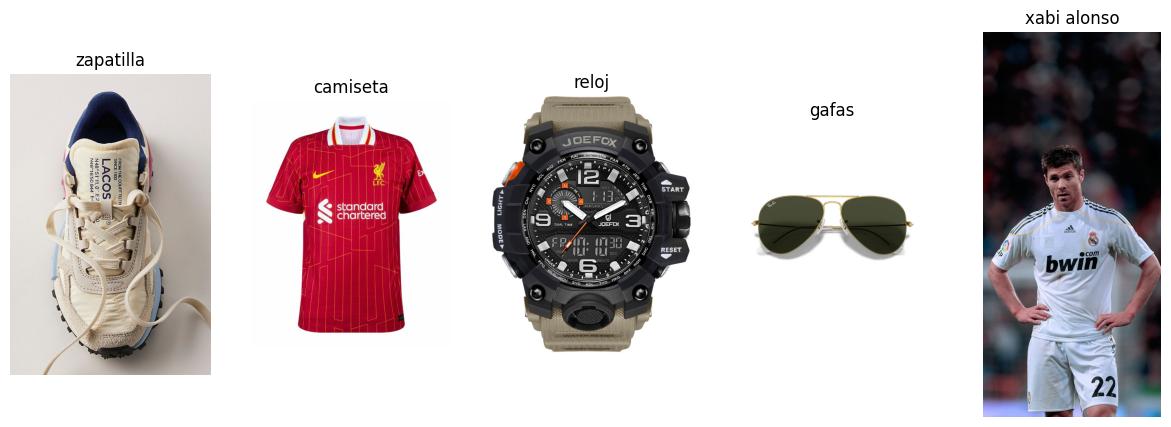

In [ ]:
# Ruta al CSV y al directorio de imágenes
csv_path = './datasets/catalogo.csv'
images_path = './datasets/catalogo/'

# Cargar el CSV
df_catalogo = pd.read_csv(csv_path)

# Mostrar las primeras filas
print(df_catalogo.head())

# Función para mostrar imágenes
def mostrar_imagenes(df, images_path, cantidad=5):
    fig, axes = plt.subplots(1, cantidad, figsize=(15, 5))
    for i, ax in enumerate(axes):
        nombre_imagen = df.iloc[i]['imagen']
        etiqueta = df.iloc[i]['label']
        img = Image.open(os.path.join(images_path, nombre_imagen))
        ax.imshow(img)
        ax.set_title(etiqueta)
        ax.axis('off')
    plt.show()

# Mostrar las imágenes
mostrar_imagenes(df_catalogo, images_path)

# Preprocesamiento 

In [ ]:
# Elegir el modelo: VGG16 o ResNet50 
modelo = 'VGG16' 

# Preprocesamiento 
modelo == 'VGG16'
preprocess_input = vgg16_preprocess
target_size = (224, 224)

# Función para preprocesar una imagen
def procesar_imagen(path_imagen):
    img = keras_image.load_img(path_imagen, target_size=target_size)
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

# Procesar todas las imágenes del catálogo
imagenes_procesadas = []
nombres_imagenes = df_catalogo['imagen'].tolist()

for nombre_imagen in nombres_imagenes:
    path = os.path.join(images_path, nombre_imagen)
    img_array = procesar_imagen(path)
    imagenes_procesadas.append(img_array)

# Convertir lista a array numpy
imagenes_procesadas = np.vstack(imagenes_procesadas)

# Confirmar tamaño de salida
print('Shape del array procesado:', imagenes_procesadas.shape)

Shape del array procesado: (5, 224, 224, 3)


# Extraer características (features) con VGG16 o ResNet50

In [ ]:
# Cargar el modelo preentrenado (sin la capa final de clasificación)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Usamos la salida del modelo como extractor de características (flatten para simplificar)
modelo_extractor = Model(inputs=base_model.input, outputs=base_model.output)

# Extraer las características
features = modelo_extractor.predict(imagenes_procesadas, verbose=1)

# Confirmar el shape de salida
print('Shape de las características extraídas:', features.shape)

# Aplanar las características para simplificar el cálculo de similitud (de 4D a 2D)
features_flat = features.reshape(features.shape[0], -1)

print('Shape después de aplanar:', features_flat.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
Shape de las características extraídas: (5, 7, 7, 512)
Shape después de aplanar: (5, 25088)


# Calcular similitud (cosseno e euclidiana)

In [16]:
# Calcular la matriz de similitud coseno
similitud_coseno = cosine_similarity(features_flat)

# Calcular la matriz de distancia euclidiana
distancia_euclidiana = euclidean_distances(features_flat)

# Mostrar ambas matrices como DataFrames para leer mejor
df_coseno = pd.DataFrame(similitud_coseno, index=nombres_imagenes, columns=nombres_imagenes)
df_euclidiana = pd.DataFrame(distancia_euclidiana, index=nombres_imagenes, columns=nombres_imagenes)

print("Similitud por coseno:")
print(df_coseno)

print("\nDistancia euclidiana:")
print(df_euclidiana)

Similitud por coseno:
             imagen1.jpg  imagen2.jpg  imagen3.jpg  imagen4.jpg  imagen5.jpg
imagen1.jpg     1.000000     0.190636     0.187852     0.090237     0.120998
imagen2.jpg     0.190636     1.000000     0.150683     0.084197     0.107002
imagen3.jpg     0.187852     0.150683     1.000000     0.122932     0.091635
imagen4.jpg     0.090237     0.084197     0.122932     1.000000     0.065606
imagen5.jpg     0.120998     0.107002     0.091635     0.065606     1.000000

Distancia euclidiana:
             imagen1.jpg  imagen2.jpg  imagen3.jpg  imagen4.jpg  imagen5.jpg
imagen1.jpg     0.000000  2907.224854  4090.187012  2589.470215  2607.978027
imagen2.jpg  2907.224854     0.000000  4171.064453  2600.782227  2630.615723
imagen3.jpg  4090.187012  4171.064453     0.000000  3942.248535  4021.222656
imagen4.jpg  2589.470215  2600.782227  3942.248535     0.000000  2061.106445
imagen5.jpg  2607.978027  2630.615723  4021.222656  2061.106445     0.000000


# Función de recomendación con visualización de las imágenes más similares

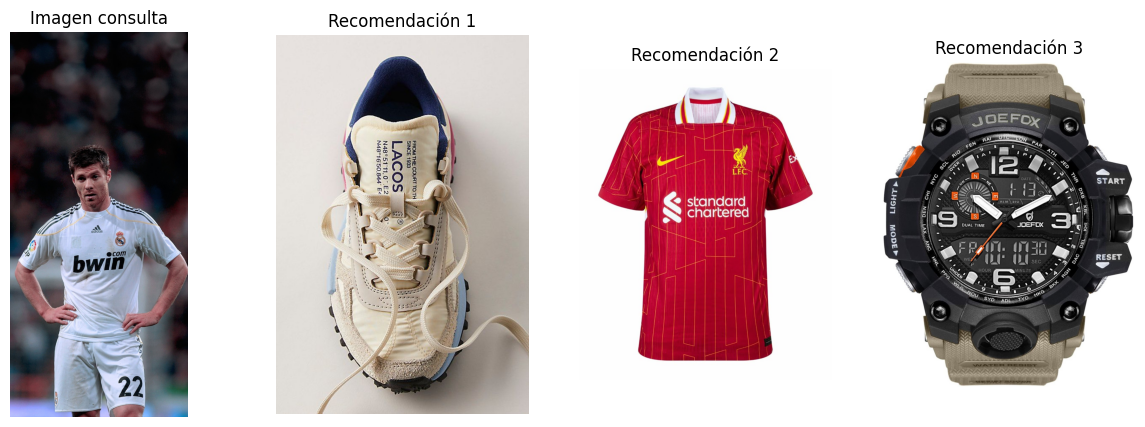

In [12]:
# Función para recomendar imágenes similares
def recomendar(imagen_nombre, df_similitud, top_n=3):
    # Excluir la propia imagen (siempre tiene 1.0 de similitud consigo misma)
    similares = df_similitud.loc[imagen_nombre].drop(labels=[imagen_nombre])
    # Ordenar de mayor a menor (mayor similitud coseno)
    recomendadas = similares.sort_values(ascending=False).head(top_n)
    return recomendadas.index.tolist()

# Función para mostrar la imagen de entrada y sus recomendaciones
def mostrar_recomendaciones(imagen_nombre, recomendaciones, images_path):
    fig, axes = plt.subplots(1, len(recomendaciones)+1, figsize=(15, 5))
    # Imagen de entrada
    img = Image.open(os.path.join(images_path, imagen_nombre))
    axes[0].imshow(img)
    axes[0].set_title('Imagen consulta')
    axes[0].axis('off')

    # Imágenes recomendadas
    for i, rec_nombre in enumerate(recomendaciones):
        img = Image.open(os.path.join(images_path, rec_nombre))
        axes[i+1].imshow(img)
        axes[i+1].set_title(f'Recomendación {i+1}')
        axes[i+1].axis('off')
    plt.show()

# Ejemplo: buscar imágenes similares a 'imagen1.jpg'
imagen_consulta = 'imagen5.jpg'
recomendaciones = recomendar(imagen_consulta, df_coseno, top_n=3)

# Mostrar resultado
mostrar_recomendaciones(imagen_consulta, recomendaciones, images_path)

# Resumen

Para este trabajo he desarrollado un sistema sencillo de recomendación de imágenes basado en similitud visual. Utilicé TensorFlow y un modelo preentrenado, VGG16, únicamente como extractor de características. Apliqué la técnica de extracción mediante embeddings, eliminando la última capa de clasificación y usando la salida convolucional para generar los vectores que representan cada imagen del catálogo.

Tras el preprocesamiento, normalicé todas las imágenes a 224x224 píxeles, asegurándome que fueran compatibles con la entrada del modelo. Cada imagen fue transformada en un vector de 25.088 dimensiones, lo que me permitió calcular las distancias de similitud con métricas de coseno y euclidiana.

En las matrices de coseno, confirmé que los valores más cercanos a 1 corresponden a la misma imagen y que el resto se encuentran bastante dispersos, evidenciando que las imágenes elegidas son de categorías muy distintas entre sí (ropa deportiva, relojes, gafas, arte). Aun así, el sistema consiguió establecer relaciones lógicas dentro de su criterio matemático.

Un caso interesante fue al utilizar como imagen de consulta una fotografía del exjugador Xabi Alonso con la camiseta blanca del Real Madrid. El sistema identificó como la imagen más parecida un calzado deportivo, no por el objeto en sí, sino por la forma que el modelo percibe. Xabi Alonso aparece con los brazos apoyados en la cintura, lo que genera una forma curvada en el centro de la imagen, similar a los cordones del zapato en forma de bucle. Además, la predominancia del color blanco en ambas imágenes refuerza la similitud visual desde el punto de vista del modelo. Por esta razón, incluso antes de la camiseta roja del Liverpool, el sistema posicionó primero el calzado.

Esta experiencia me permitió entender que el modelo no comprende el contenido semántico, sino que calcula similitudes entre formas, colores y estructuras visuales. Si bien la camiseta del Liverpool podría parecer más obvia para un humano, el algoritmo prioriza las coincidencias visuales antes que las conceptuales.

Mi nivel sigue siendo júnior, por lo que este trabajo me ha servido para reforzar conceptos básicos de visión por computador, embeddings, métricas de distancia y la importancia de entender cómo un modelo interpreta una imagen desde una perspectiva puramente matemática.